<a href="https://colab.research.google.com/github/valsson-group/UNT-ChemicalApplicationsOfMachineLearning-Spring2026/blob/main/Lecture-12_March-3-2026/Lecture-12_Regression-1_Solutions.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Lecture 12 - Regression



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Here we create an example dataset for regression

In [8]:
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split


n_samples=1000

features, target = make_regression(
    n_samples=n_samples,
    n_features=20,
    n_informative=8,
    shuffle=True,
    noise=20.0
)

feature_names = [f"feature {i}" for i in range(features.shape[1])]


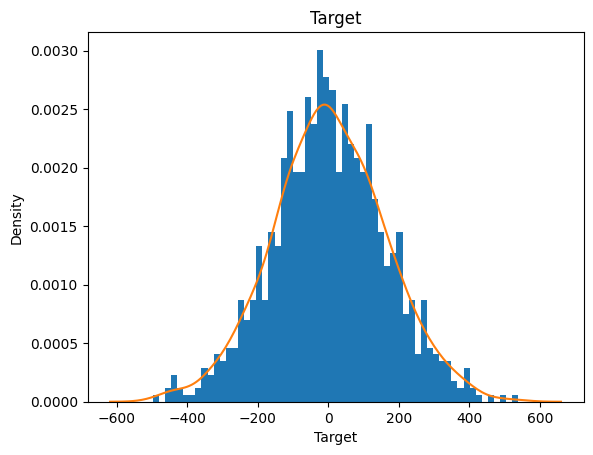

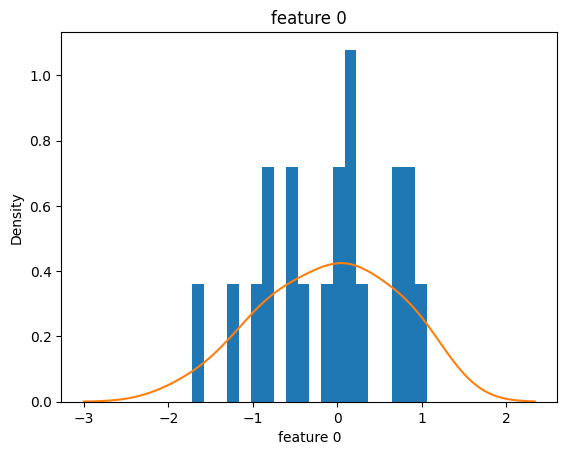

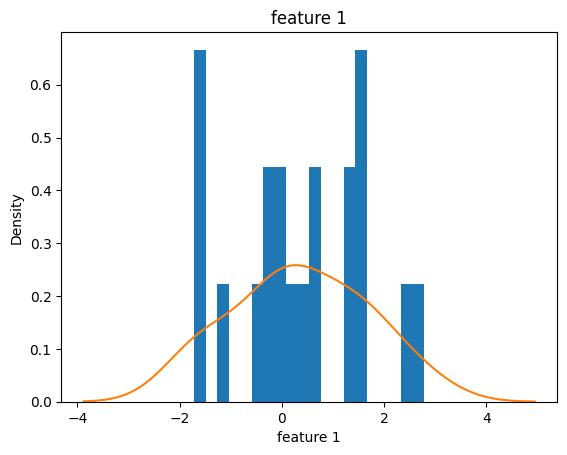

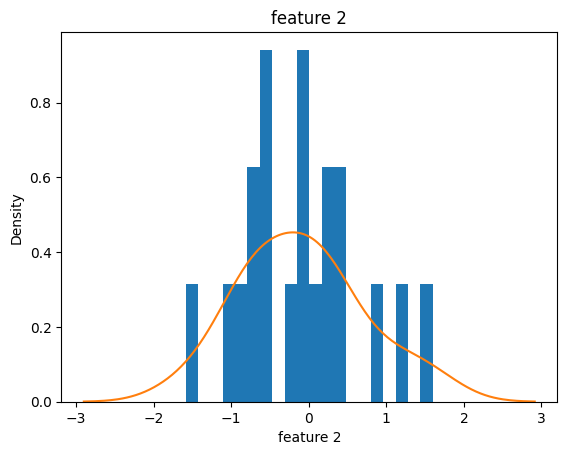

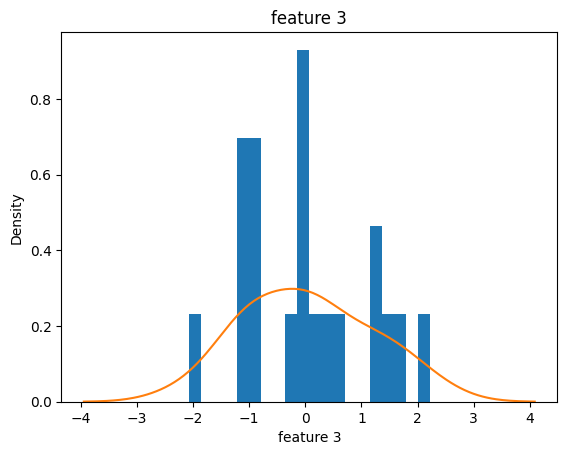

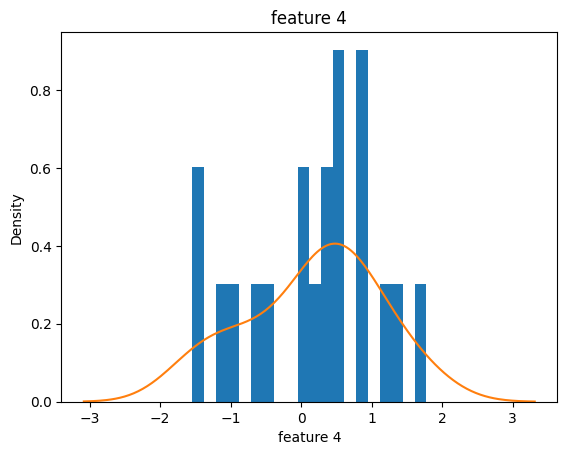

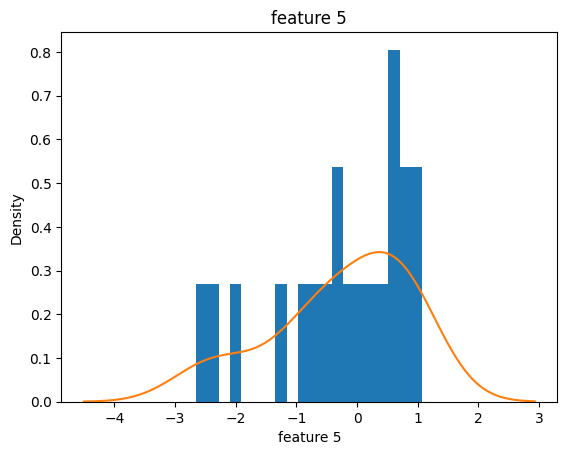

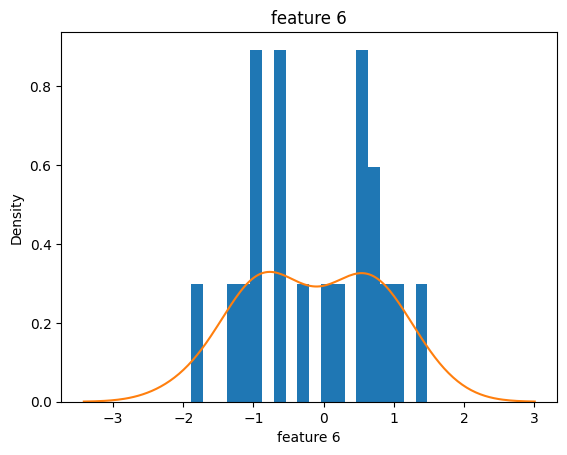

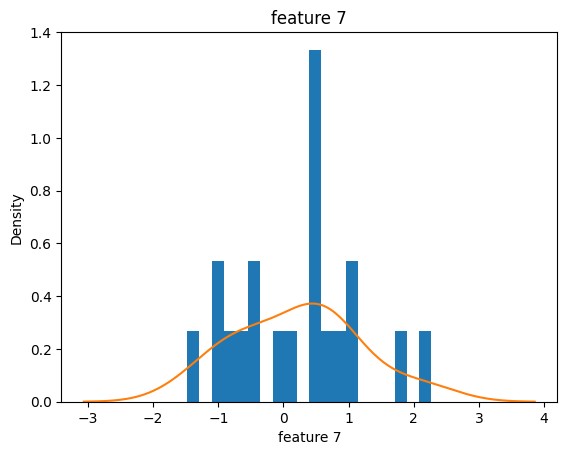

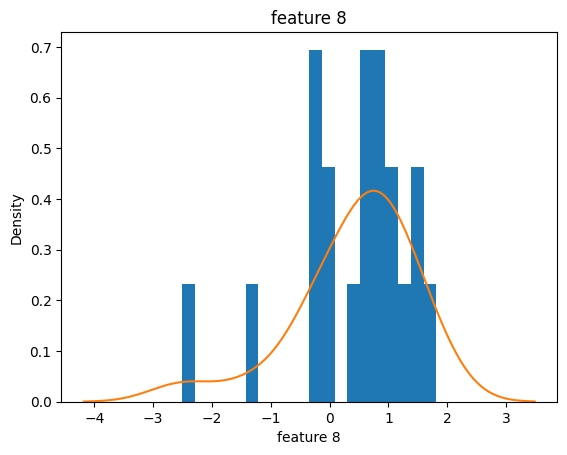

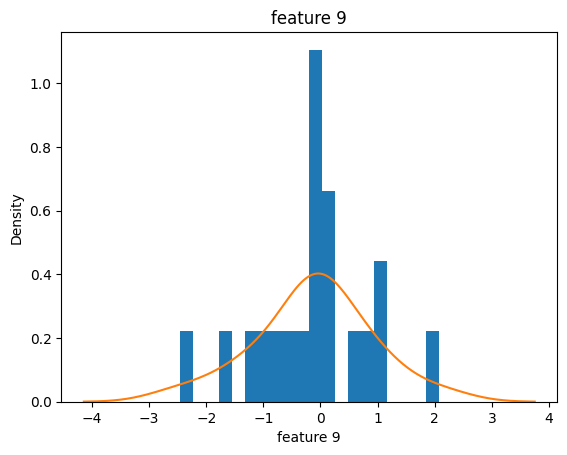

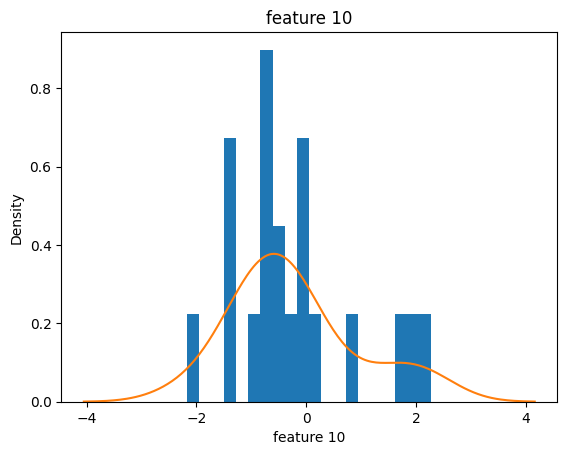

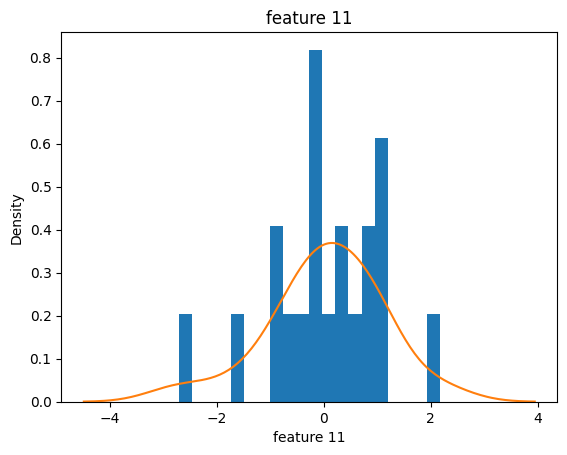

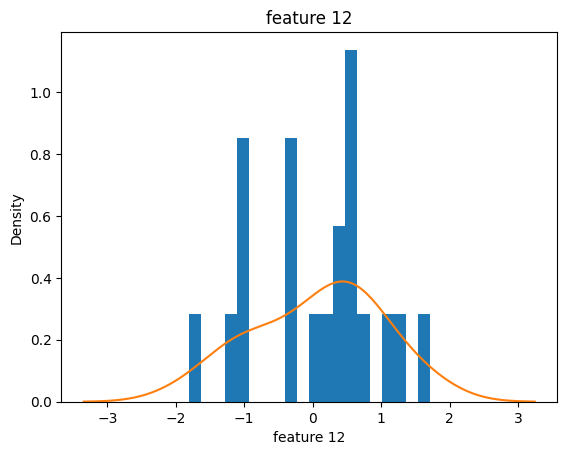

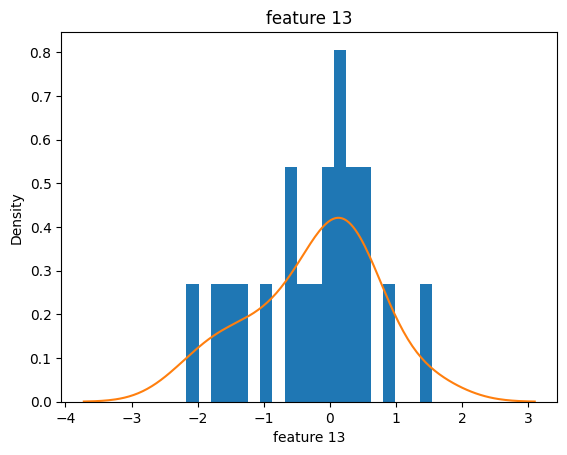

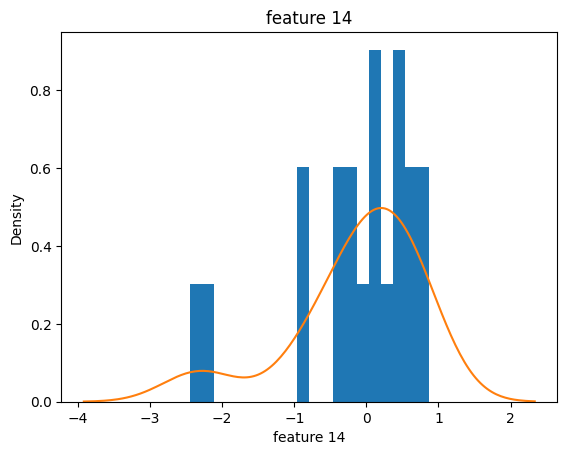

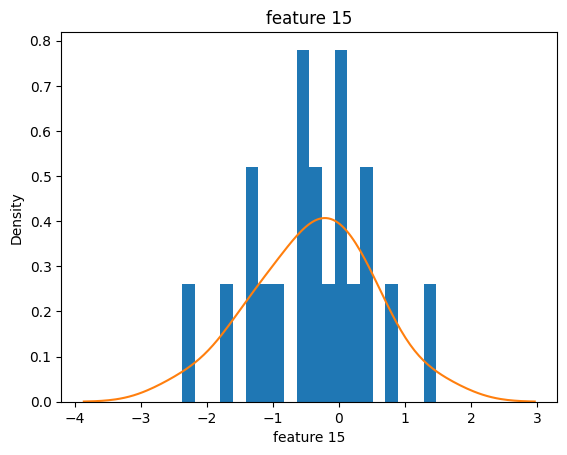

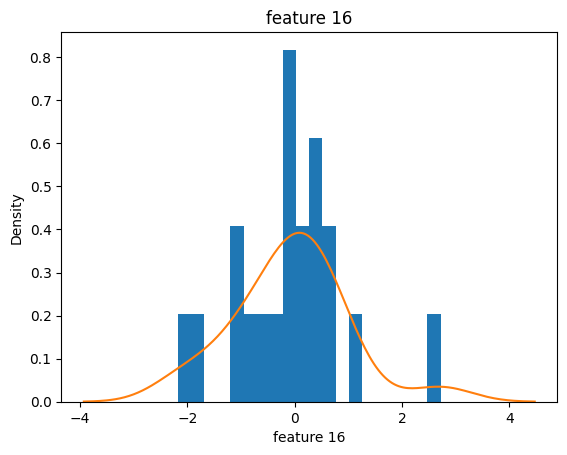

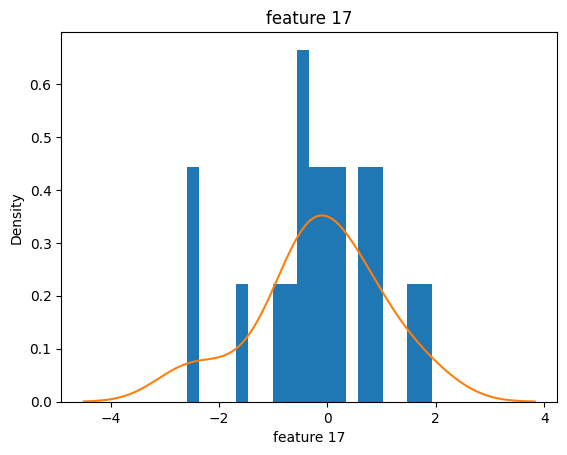

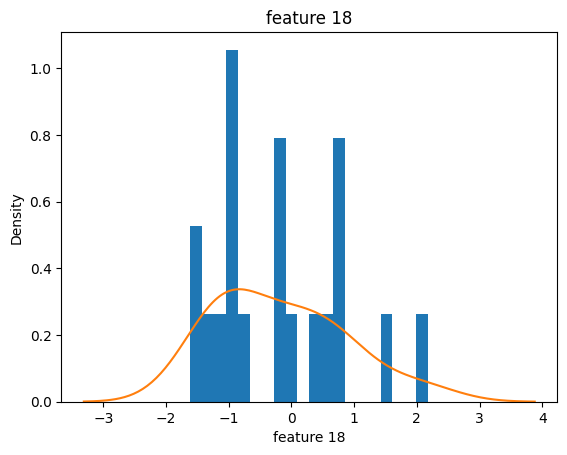

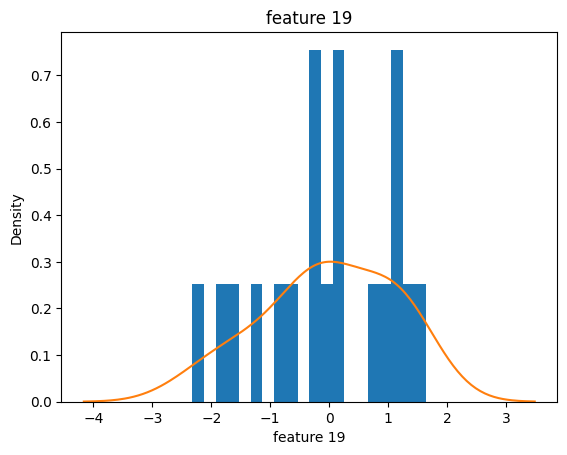

In [9]:
plt.hist(target,bins=60,density=True,label='Discrete Histogram')
sns.kdeplot(target,label='KDE')
plt.title("Target")
plt.xlabel("Target")
plt.show()

for i in range(features.shape[1]):
  plt.hist(features[i],bins=20,density=True,label='Discrete Histogram')
  sns.kdeplot(features[i],label='KDE')
  plt.title(feature_names[i])
  plt.xlabel(feature_names[i])
  plt.show()





R^2 score
- training set: 0.977
- test set:     0.836


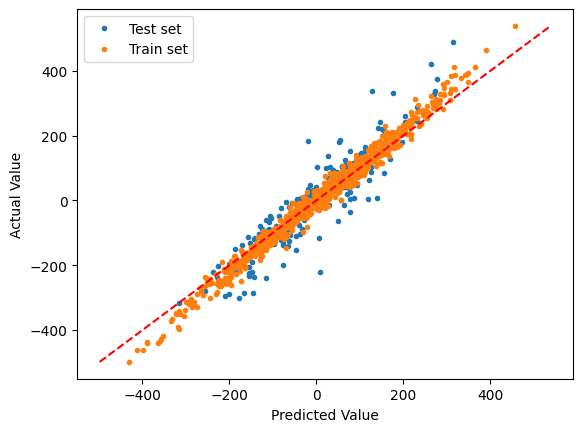

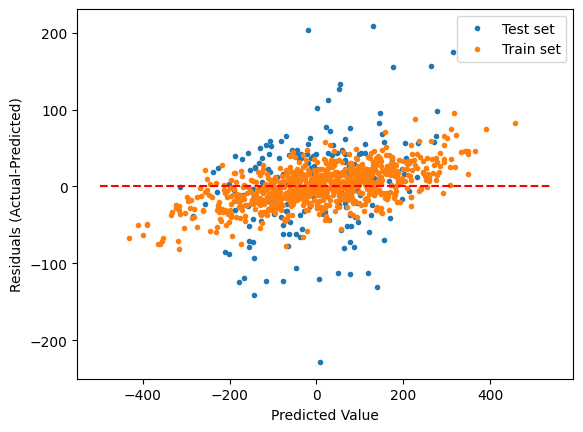

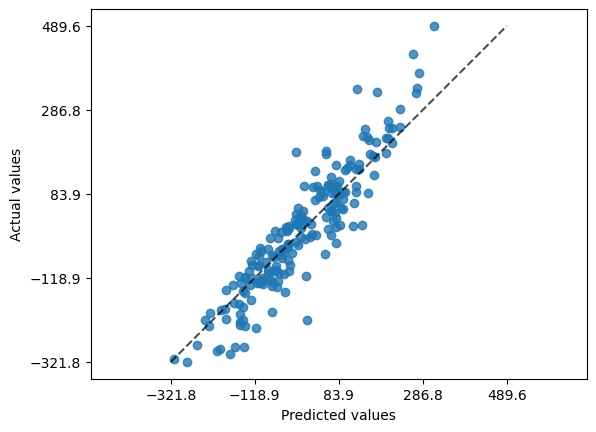

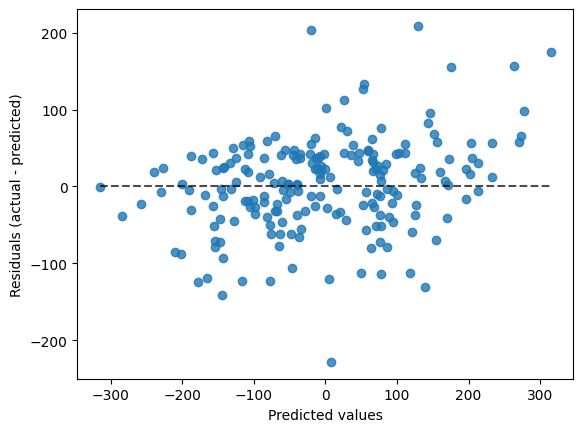

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import PredictionErrorDisplay

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2)

model = RandomForestRegressor()

model.fit(features_train,target_train)

train_r2 = model.score(features_train,target_train)
test_r2 = model.score(features_test,target_test)

print("R^2 score")
print("- training set: {:.3f}".format(train_r2))
print("- test set:     {:.3f}".format(test_r2))

target_train_predicted = model.predict(features_train)
target_test_predicted = model.predict(features_test)

plt.plot(target_test_predicted, target_test,'.',label='Test set')
plt.plot(target_train_predicted, target_train,'.',label='Train set')
# to get a diagonal line
diagonal_line =np.linspace(np.min(target),np.max(target),1000)
plt.plot(diagonal_line,diagonal_line, color='red', linestyle='--')
# plt.axline([0, 0], slope=1, color='red', linestyle='--')
plt.legend()
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

plt.plot(target_test_predicted, target_test-target_test_predicted,'.',label='Test set')
plt.plot(target_train_predicted, target_train-target_train_predicted,'.',label='Train set')
yzero_line =np.linspace(np.min(target),np.max(target),1000)
plt.plot(yzero_line, np.zeros(diagonal_line.size), color='red', linestyle='--')
# plt.axline([0, 0], slope=0, color='red', linestyle='--')
plt.legend()
plt.xlabel("Predicted Value")
plt.ylabel("Residuals (Actual-Predicted)")
plt.show()



display = PredictionErrorDisplay.from_predictions(y_true=target_test, y_pred=target_test_predicted,kind="actual_vs_predicted")
display.plot()

Feature importance

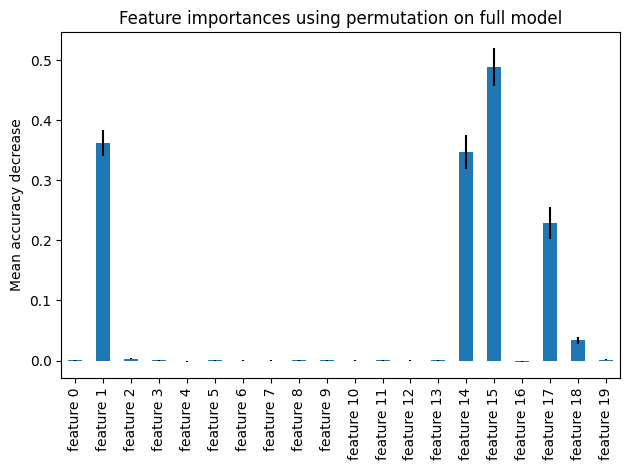

In [11]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.inspection import permutation_importance

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2)

model = RandomForestRegressor()

model.fit(features_train,target_train)

result = permutation_importance(
    model, features_test, target_test, n_repeats=10, random_state=42, n_jobs=2
)

feature_importances = pd.Series(result.importances_mean, index=feature_names)

fig, ax = plt.subplots()
feature_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()



Let's do cross validation

In [12]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_validate,ShuffleSplit


model = RandomForestRegressor()

target_used = target.copy()

scoring =['neg_mean_absolute_error',
          'neg_root_mean_squared_error',
          'neg_max_error',
          'r2']

# employ 5-fold CV
scores_fold = cross_validate(
    model,
    features, target_used,
    scoring=scoring,
    cv=5,
    return_train_score=True,
    return_estimator=True,
    return_indices=True
)

NumSplits=100
cv_random = ShuffleSplit(n_splits=NumSplits, test_size=0.20)
scores_random = cross_validate(
    model,
    features, target_used,
    scoring=scoring,
    cv=cv_random,
    return_train_score=True,
    return_estimator=True,
    return_indices=True
)

for s in scoring:
  print("Score: {:s}".format(s))
  print("- Training set: {:s}".format(s))
  print("  - 5-Fold CV                   : {:.3f} +- {:.3f}".format( np.nanmean(scores_fold['train_'+s]),np.nanstd(scores_fold['train_'+s])))
  print("  - Random Splits ({:d} splits) : {:.3f} +- {:.3f}".format(NumSplits, np.nanmean(scores_random['train_'+s]), np.nanstd(scores_random['train_'+s])))
  print("- Test set: {:s}".format(s))
  print("  - 5-Fold CV                   : {:.3f} +- {:.3f}".format( np.nanmean(scores_fold['test_'+s]),np.nanstd(scores_fold['test_'+s])))
  print("  - Random Splits ({:d} splits) : {:.3f} +- {:.3f}".format(NumSplits, np.nanmean(scores_random['test_'+s]), np.nanstd(scores_random['test_'+s])))
  print("")



Score: neg_mean_absolute_error
- Training set: neg_mean_absolute_error
  - 5-Fold CV                   : -18.579 +- 0.155
  - Random Splits (100 splits) : -18.533 +- 0.293
- Test set: neg_mean_absolute_error
  - 5-Fold CV                   : -49.169 +- 2.512
  - Random Splits (100 splits) : -48.590 +- 3.361

Score: neg_root_mean_squared_error
- Training set: neg_root_mean_squared_error
  - 5-Fold CV                   : -24.471 +- 0.242
  - Random Splits (100 splits) : -24.508 +- 0.394
- Test set: neg_root_mean_squared_error
  - 5-Fold CV                   : -64.807 +- 3.869
  - Random Splits (100 splits) : -63.803 +- 4.653

Score: neg_max_error
- Training set: neg_max_error
  - 5-Fold CV                   : -107.872 +- 8.291
  - Random Splits (100 splits) : -102.885 +- 7.760
- Test set: neg_max_error
  - 5-Fold CV                   : -236.903 +- 17.263
  - Random Splits (100 splits) : -226.488 +- 28.130

Score: r2
- Training set: r2
  - 5-Fold CV                   : 0.977 +- 0.001
  - 

Let's do kNN regression

We can also use some of the example dataset available in sklearn

In [16]:
from sklearn.datasets import load_diabetes

features, target = load_diabetes(return_X_y=True)

feature_names = [f"feature {i}" for i in range(features.shape[1])]


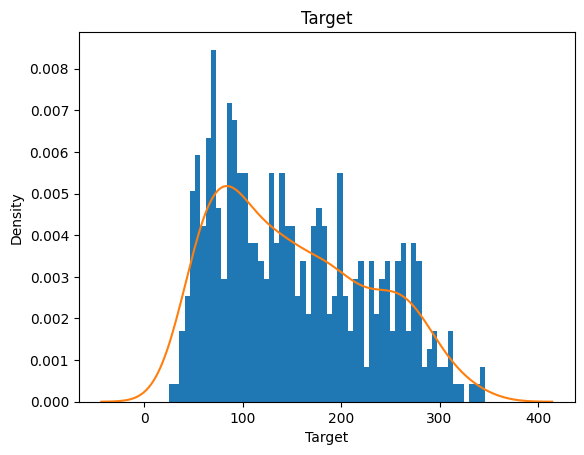

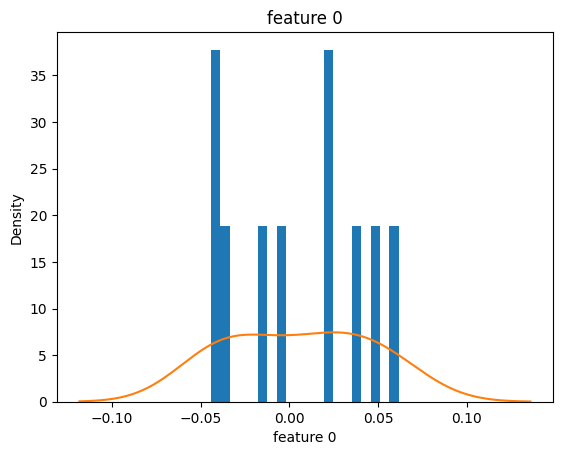

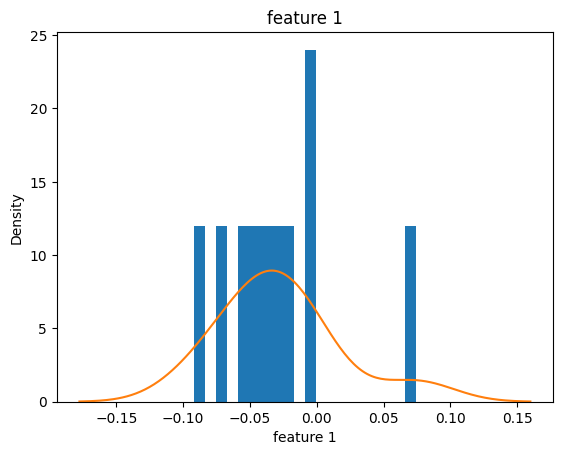

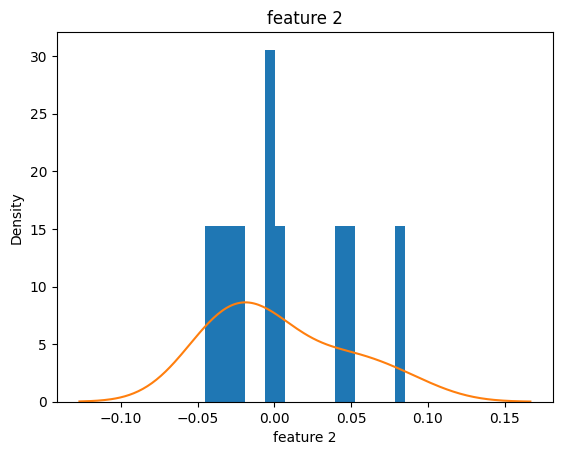

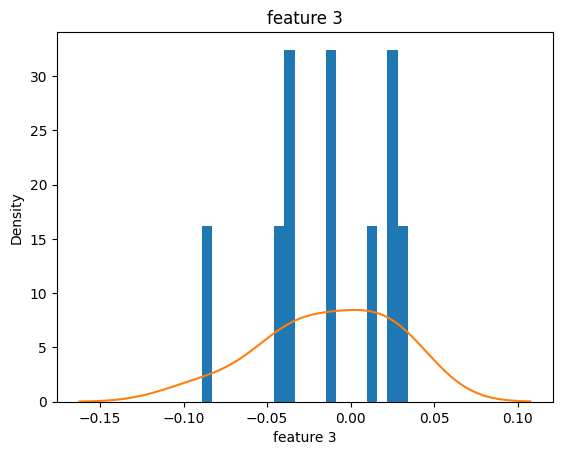

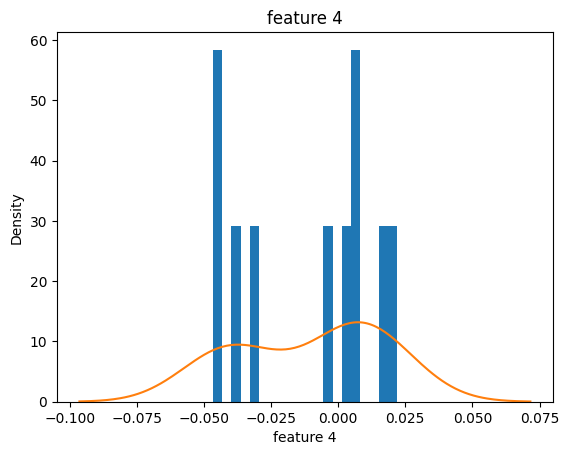

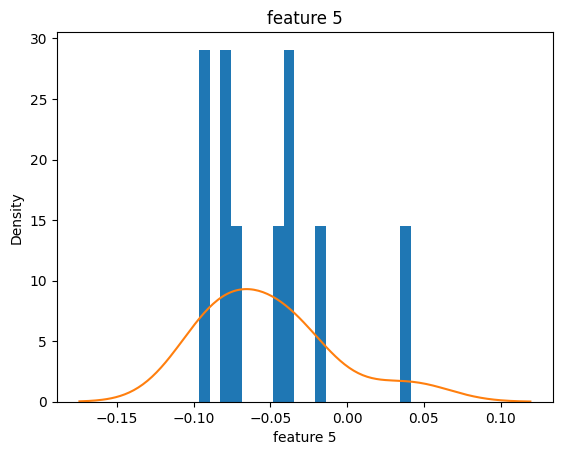

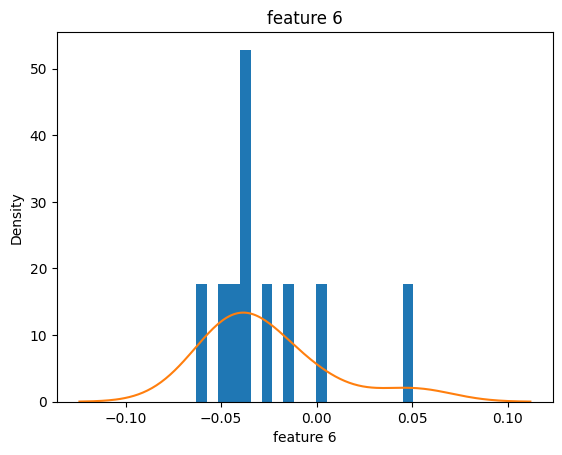

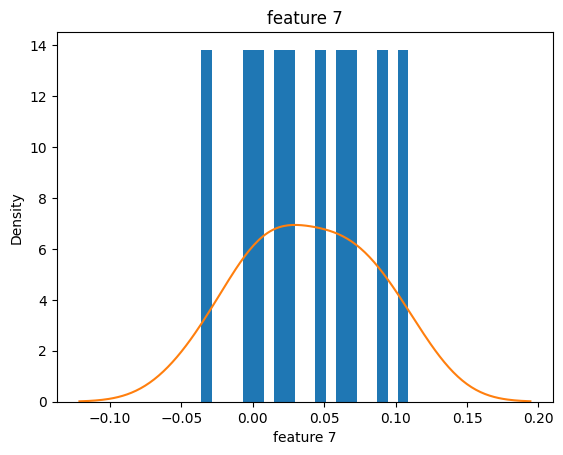

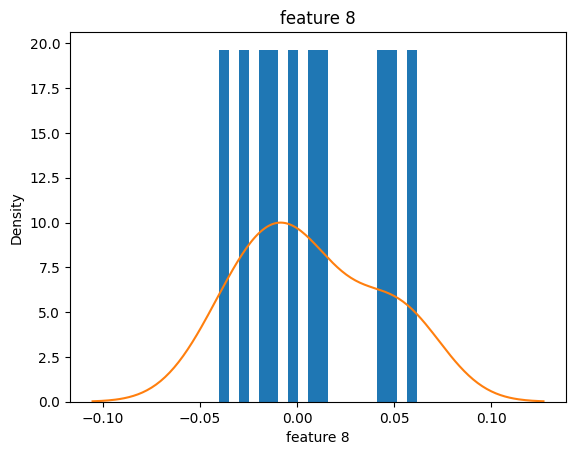

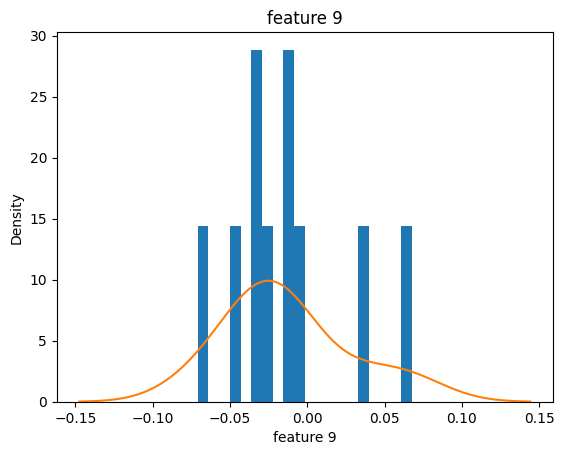

In [17]:
plt.hist(target,bins=60,density=True,label='Discrete Histogram')
sns.kdeplot(target,label='KDE')
plt.title("Target")
plt.xlabel("Target")
plt.show()

for i in range(features.shape[1]):
  plt.hist(features[i],bins=20,density=True,label='Discrete Histogram')
  sns.kdeplot(features[i],label='KDE')
  plt.title(feature_names[i])
  plt.xlabel(feature_names[i])
  plt.show()

R^2 score
- training set: 0.914
- test set:     0.505


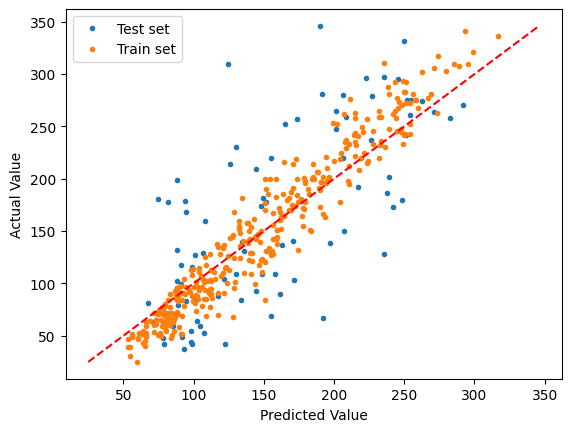

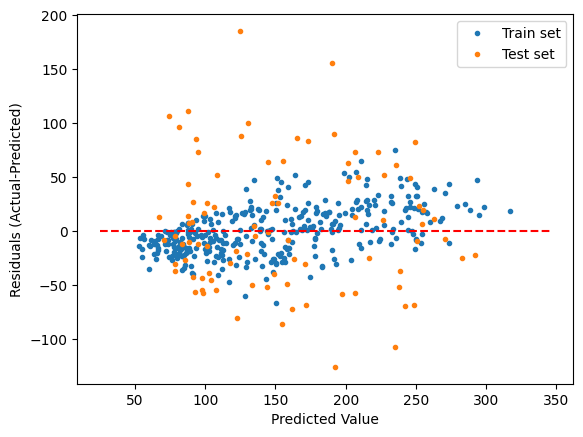

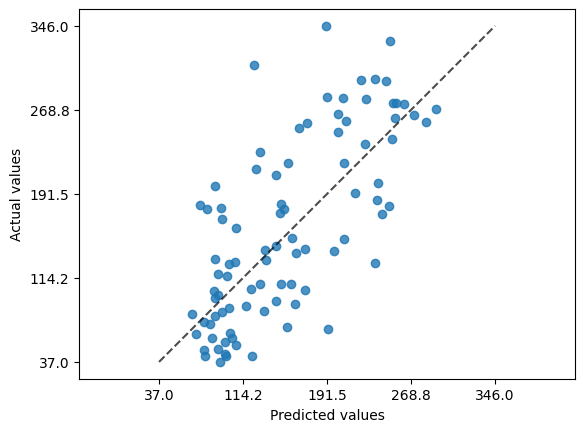

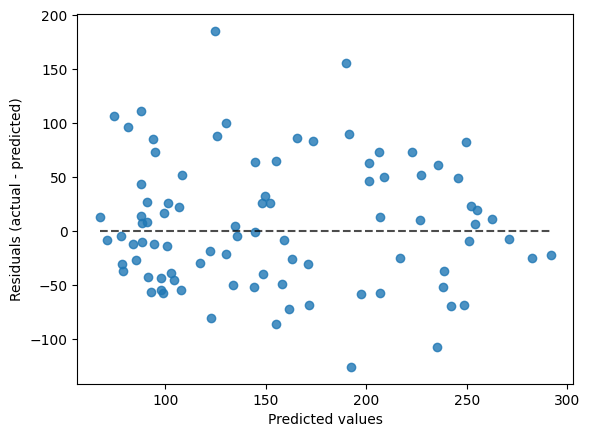

In [19]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.metrics import PredictionErrorDisplay

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2)

model = RandomForestRegressor()

model.fit(features_train,target_train)

train_r2 = model.score(features_train,target_train)
test_r2 = model.score(features_test,target_test)

print("R^2 score")
print("- training set: {:.3f}".format(train_r2))
print("- test set:     {:.3f}".format(test_r2))

target_train_predicted = model.predict(features_train)
target_test_predicted = model.predict(features_test)

plt.plot(target_test_predicted, target_test,'.',label='Test set')
plt.plot(target_train_predicted, target_train,'.',label='Train set')
diagonal_line =np.linspace(np.min(target),np.max(target),1000)
plt.plot(diagonal_line,diagonal_line, color='red', linestyle='--')
# plt.axline([0, 0], slope=1, color='red', linestyle='--')
plt.legend()
plt.xlabel("Predicted Value")
plt.ylabel("Actual Value")
plt.show()

plt.plot(target_train_predicted, target_train-target_train_predicted,'.',label='Train set')
plt.plot(target_test_predicted, target_test-target_test_predicted,'.',label='Test set')
diagonal_line =np.linspace(np.min(target),np.max(target),1000)
plt.plot(diagonal_line, np.zeros(diagonal_line.size), color='red', linestyle='--')
# plt.axline([0, 0], slope=0, color='red', linestyle='--')
plt.legend()
plt.xlabel("Predicted Value")
plt.ylabel("Residuals (Actual-Predicted)")
plt.show()



display = PredictionErrorDisplay.from_predictions(y_true=target_test, y_pred=target_test_predicted,kind="actual_vs_predicted")
display.plot()

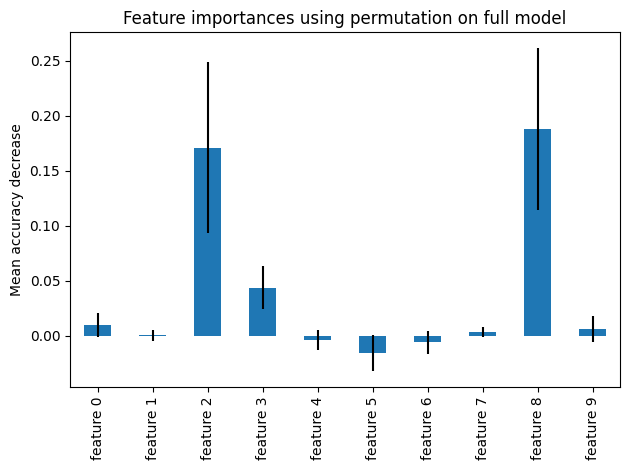

In [20]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.inspection import permutation_importance

features_train, features_test, target_train, target_test = train_test_split(features, target, test_size=0.2)

model = RandomForestRegressor()

model.fit(features_train,target_train)

result = permutation_importance(
    model, features_test, target_test, n_repeats=10, random_state=42, n_jobs=2
)

feature_importances = pd.Series(result.importances_mean, index=feature_names)

fig, ax = plt.subplots()
feature_importances.plot.bar(yerr=result.importances_std, ax=ax)
ax.set_title("Feature importances using permutation on full model")
ax.set_ylabel("Mean accuracy decrease")
fig.tight_layout()
plt.show()

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_validate,ShuffleSplit


model = RandomForestRegressor()

target_used = target.copy()

scoring =['neg_mean_absolute_error',
          'neg_mean_squared_error',
          'neg_root_mean_squared_error',
          'neg_max_error',
          'r2']

# employ 5-fold CV
scores_fold = cross_validate(
    model,
    features, target_used,
    scoring=scoring,
    cv=5,
    return_train_score=True,
    return_estimator=True,
    return_indices=True
)

NumSplits=100
cv_random = ShuffleSplit(n_splits=NumSplits, test_size=0.20)
scores_random = cross_validate(
    model,
    features, target_used,
    scoring=scoring,
    cv=cv_random,
    return_train_score=True,
    return_estimator=True,
    return_indices=True
)

for s in scoring:
  print("Score: {:s}".format(s))
  print("- Training set: {:s}".format(s))
  print("  - 5-Fold CV                   : {:.3f} +- {:.3f}".format( np.nanmean(scores_fold['train_'+s]),np.nanstd(scores_fold['train_'+s])))
  print("  - Random Splits ({:d} splits) : {:.3f} +- {:.3f}".format(NumSplits, np.nanmean(scores_random['train_'+s]), np.nanstd(scores_random['train_'+s])))
  print("- Test set: {:s}".format(s))
  print("  - 5-Fold CV                   : {:.3f} +- {:.3f}".format( np.nanmean(scores_fold['test_'+s]),np.nanstd(scores_fold['test_'+s])))
  print("  - Random Splits ({:d} splits) : {:.3f} +- {:.3f}".format(NumSplits, np.nanmean(scores_random['test_'+s]), np.nanstd(scores_random['test_'+s])))
  print("")

Score: neg_mean_absolute_error
- Training set: neg_mean_absolute_error
  - 5-Fold CV                   : -17.571 +- 0.351
  - Random Splits (100 splits) : -17.497 +- 0.433
- Test set: neg_mean_absolute_error
  - 5-Fold CV                   : -47.114 +- 2.410
  - Random Splits (100 splits) : -46.975 +- 3.250

Score: neg_mean_squared_error
- Training set: neg_mean_squared_error
  - 5-Fold CV                   : -481.608 +- 19.341
  - Random Splits (100 splits) : -474.453 +- 22.370
- Test set: neg_mean_squared_error
  - 5-Fold CV                   : -3347.729 +- 267.336
  - Random Splits (100 splits) : -3376.938 +- 423.455

Score: neg_root_mean_squared_error
- Training set: neg_root_mean_squared_error
  - 5-Fold CV                   : -21.941 +- 0.436
  - Random Splits (100 splits) : -21.776 +- 0.513
- Test set: neg_root_mean_squared_error
  - 5-Fold CV                   : -57.814 +- 2.304
  - Random Splits (100 splits) : -57.993 +- 3.701

Score: neg_max_error
- Training set: neg_max_erro

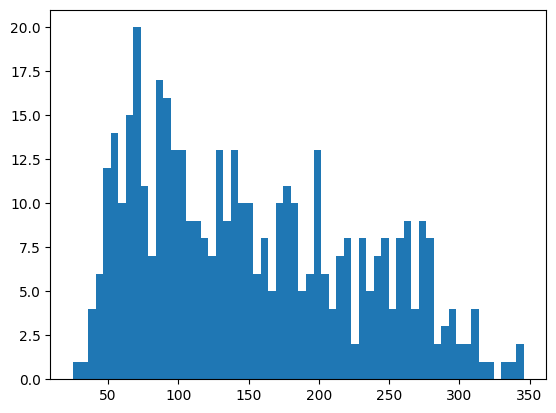

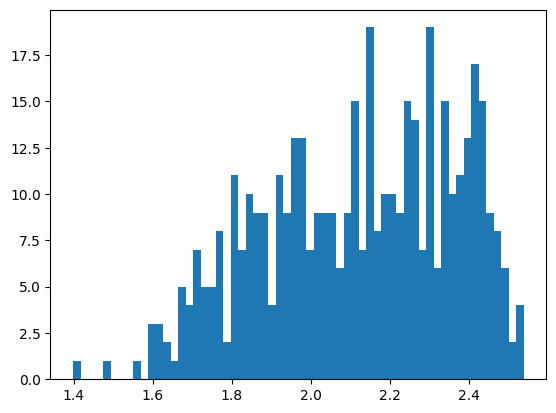

In [24]:
plt.hist(target,bins=60)
plt.show()

plt.hist(np.log10(target),bins=60)
plt.show()

In [22]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_validate,ShuffleSplit


model = RandomForestRegressor()

target_used = np.log10(target)

scoring =['neg_mean_absolute_error',
          'neg_mean_squared_error',
          'neg_root_mean_squared_error',
          'neg_max_error',
          'r2']

# employ 5-fold CV
scores_fold = cross_validate(
    model,
    features, target_used,
    scoring=scoring,
    cv=5,
    return_train_score=True,
    return_estimator=True,
    return_indices=True
)

NumSplits=100
cv_random = ShuffleSplit(n_splits=NumSplits, test_size=0.2)
scores_random = cross_validate(
    model,
    features, target_used,
    scoring=scoring,
    cv=cv_random,
    return_train_score=True,
    return_estimator=True,
    return_indices=True
)

for s in scoring:
  print("Score: {:s}".format(s))
  print("- Training set: {:s}".format(s))
  print("  - 5-Fold CV                   : {:.3f} +- {:.3f}".format( np.nanmean(scores_fold['train_'+s]),np.nanstd(scores_fold['train_'+s])))
  print("  - Random Splits ({:d} splits) : {:.3f} +- {:.3f}".format(NumSplits, np.nanmean(scores_random['train_'+s]), np.nanstd(scores_random['train_'+s])))
  print("- Test set: {:s}".format(s))
  print("  - 5-Fold CV                   : {:.3f} +- {:.3f}".format( np.nanmean(scores_fold['test_'+s]),np.nanstd(scores_fold['test_'+s])))
  print("  - Random Splits ({:d} splits) : {:.3f} +- {:.3f}".format(NumSplits, np.nanmean(scores_random['test_'+s]), np.nanstd(scores_random['test_'+s])))
  print("")



Score: neg_mean_absolute_error
- Training set: neg_mean_absolute_error
  - 5-Fold CV                   : -0.057 +- 0.002
  - Random Splits (100 splits) : -0.056 +- 0.001
- Test set: neg_mean_absolute_error
  - 5-Fold CV                   : -0.152 +- 0.009
  - Random Splits (100 splits) : -0.150 +- 0.011

Score: neg_mean_squared_error
- Training set: neg_mean_squared_error
  - 5-Fold CV                   : -0.005 +- 0.000
  - Random Splits (100 splits) : -0.005 +- 0.000
- Test set: neg_mean_squared_error
  - 5-Fold CV                   : -0.036 +- 0.003
  - Random Splits (100 splits) : -0.035 +- 0.005

Score: neg_root_mean_squared_error
- Training set: neg_root_mean_squared_error
  - 5-Fold CV                   : -0.071 +- 0.001
  - Random Splits (100 splits) : -0.071 +- 0.002
- Test set: neg_root_mean_squared_error
  - 5-Fold CV                   : -0.189 +- 0.007
  - Random Splits (100 splits) : -0.187 +- 0.013

Score: neg_max_error
- Training set: neg_max_error
  - 5-Fold CV         

In [27]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import train_test_split
from sklearn import metrics
from sklearn.model_selection import cross_validate,ShuffleSplit


model = KNeighborsRegressor(n_neighbors=5)

target_used = target.copy()

scoring =['neg_mean_absolute_error',
          'neg_mean_squared_error',
          'neg_root_mean_squared_error',
          'neg_max_error',
          'r2']

# employ 5-fold CV
scores_fold = cross_validate(
    model,
    features, target_used,
    scoring=scoring,
    cv=5,
    return_train_score=True,
    return_estimator=True,
    return_indices=True
)

NumSplits=100
cv_random = ShuffleSplit(n_splits=NumSplits, test_size=0.20)
scores_random = cross_validate(
    model,
    features, target_used,
    scoring=scoring,
    cv=cv_random,
    return_train_score=True,
    return_estimator=True,
    return_indices=True
)

for s in scoring:
  print("Score: {:s}".format(s))
  print("- Training set: {:s}".format(s))
  print("  - 5-Fold CV                   : {:.3f} +- {:.3f}".format( np.nanmean(scores_fold['train_'+s]),np.nanstd(scores_fold['train_'+s])))
  print("  - Random Splits ({:d} splits) : {:.3f} +- {:.3f}".format(NumSplits, np.nanmean(scores_random['train_'+s]), np.nanstd(scores_random['train_'+s])))
  print("- Test set: {:s}".format(s))
  print("  - 5-Fold CV                   : {:.3f} +- {:.3f}".format( np.nanmean(scores_fold['test_'+s]),np.nanstd(scores_fold['test_'+s])))
  print("  - Random Splits ({:d} splits) : {:.3f} +- {:.3f}".format(NumSplits, np.nanmean(scores_random['test_'+s]), np.nanstd(scores_random['test_'+s])))
  print("")

Score: neg_mean_absolute_error
- Training set: neg_mean_absolute_error
  - 5-Fold CV                   : -38.688 +- 0.466
  - Random Splits (100 splits) : -38.313 +- 0.834
- Test set: neg_mean_absolute_error
  - 5-Fold CV                   : -47.164 +- 2.306
  - Random Splits (100 splits) : -48.064 +- 3.214

Score: neg_mean_squared_error
- Training set: neg_mean_squared_error
  - 5-Fold CV                   : -2439.041 +- 25.944
  - Random Splits (100 splits) : -2403.648 +- 96.442
- Test set: neg_mean_squared_error
  - 5-Fold CV                   : -3620.916 +- 286.614
  - Random Splits (100 splits) : -3708.478 +- 450.226

Score: neg_root_mean_squared_error
- Training set: neg_root_mean_squared_error
  - 5-Fold CV                   : -49.386 +- 0.263
  - Random Splits (100 splits) : -49.017 +- 0.982
- Test set: neg_root_mean_squared_error
  - 5-Fold CV                   : -60.126 +- 2.395
  - Random Splits (100 splits) : -60.785 +- 3.689

Score: neg_max_error
- Training set: neg_max_er